In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
print(tf.__version__)

2.9.1


In [6]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,  # Scale pixel values to [0, 1]
    rotation_range=20,  # Randomly rotate images by up to 20 degrees
    width_shift_range=0.2,  # Randomly shift the width of the image
    height_shift_range=0.2,  # Randomly shift the height of the image
    horizontal_flip=True,  # Randomly flip images horizontally
    shear_range=0.2,  # Shear transformations
    zoom_range=0.2,  # Randomly zoom into images
    brightness_range=[0.5, 1.5],  # Randomly adjust brightness
    fill_mode="nearest"  # Fill in missing pixels using the nearest neighbor
)

test_datagen = ImageDataGenerator(
    rescale=1.0 / 255 # Scale pixel values to [0, 1]
)

val_datagen = ImageDataGenerator(
    rescale=1.0 / 255,  # Scale pixel values to [0, 1]
    rotation_range=20,  # Randomly rotate images by up to 20 degrees
    width_shift_range=0.2,  # Randomly shift the width of the image
    height_shift_range=0.2,  # Randomly shift the height of the image
    horizontal_flip=True,  # Randomly flip images horizontally
    shear_range=0.2,  # Shear transformations
    zoom_range=0.2,  # Randomly zoom into images
    brightness_range=[0.5, 1.5],  # Randomly adjust brightness
    fill_mode="nearest"  # Fill in missing pixels using the nearest neighbor
)


In [7]:
train_generator = train_datagen.flow_from_directory(
    'train',
    target_size=(224, 224),  # Resize images to a specific size
    batch_size=8,  # Set the batch size based on your hardware capabilities
    class_mode='categorical',  # Specify the type of classification task
    shuffle=True  # Shuffle the data for better training
)

test_generator = test_datagen.flow_from_directory(
    'test',
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical',
    shuffle=False  # Don't shuffle the test data
)

val_generator = val_datagen.flow_from_directory(
    'val',
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical',
    shuffle=True  # Don't shuffle the test data
)

Found 286 images belonging to 3 classes.
Found 85 images belonging to 3 classes.
Found 43 images belonging to 3 classes.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


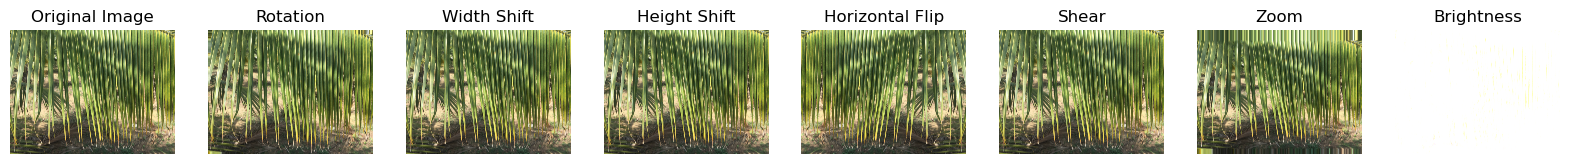

In [10]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load an image from a local path
image_path = 'train/healthy/IMG_0029.JPG'
original_image = cv2.imread(image_path)

# Convert the image from BGR to RGB (OpenCV loads images in BGR format)
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

# Create a subplot with 1 row and 8 columns for visualizing the original image and its augmented versions
fig, ax = plt.subplots(nrows=1, ncols=8, figsize=(20, 20))

# Plot the original image
ax[0].imshow(original_image)
ax[0].set_title('Original Image')
ax[0].axis('off')

# Create an ImageDataGenerator for augmentations
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    shear_range=0.2,
    zoom_range=0.2,
    brightness_range=[0.5, 1.5],
    fill_mode="nearest"
)

# Apply augmentations to the original image and plot them
augmentations = [
    ("Rotation", train_datagen.apply_transform(original_image, {'theta': np.random.uniform(-20, 20)})),
    ("Width Shift", train_datagen.apply_transform(original_image, {'tx': np.random.uniform(-0.2, 0.2)})),
    ("Height Shift", train_datagen.apply_transform(original_image, {'ty': np.random.uniform(-0.2, 0.2)})),
    ("Horizontal Flip", train_datagen.apply_transform(original_image, {'flip_horizontal': True})),
    ("Shear", train_datagen.apply_transform(original_image, {'shear': np.random.uniform(-0.2, 0.2)})),
    ("Zoom", train_datagen.apply_transform(original_image, {'zx': np.random.uniform(0.8, 1.2), 'zy': np.random.uniform(0.8, 1.2)})),
    ("Brightness", train_datagen.apply_transform(original_image, {'brightness': np.random.uniform(0.5, 1.5)})),
]

for i, (augmentation_name, augmented_image) in enumerate(augmentations, start=1):
    ax[i].imshow(augmented_image)
    ax[i].set_title(augmentation_name)
    ax[i].axis('off')

# Show the plot with the original and augmented images
plt.show()


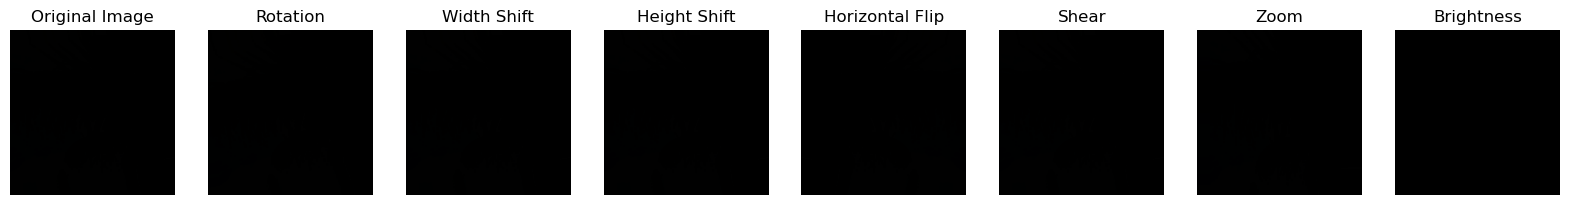

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Create a subplot with 1 row and 8 columns for visualizing an original image and its augmented versions
fig, ax = plt.subplots(nrows=1, ncols=8, figsize=(20, 20))

# Generate an original image
original_image = next(train_generator)[0][0].astype('uint8')  # Get a single original image

# Plot the original image
ax[0].imshow(original_image)
ax[0].set_title('Original Image')
ax[0].axis('off')

# Apply various augmentations to the original image and plot them
augmentations = [
    ("Rotation", train_datagen.apply_transform(original_image, {'theta': np.random.uniform(-20, 20)})),
    ("Width Shift", train_datagen.apply_transform(original_image, {'tx': np.random.uniform(-0.2, 0.2)})),
    ("Height Shift", train_datagen.apply_transform(original_image, {'ty': np.random.uniform(-0.2, 0.2)})),
    ("Horizontal Flip", train_datagen.apply_transform(original_image, {'flip_horizontal': True})),
    ("Shear", train_datagen.apply_transform(original_image, {'shear': np.random.uniform(-0.2, 0.2)})),
    ("Zoom", train_datagen.apply_transform(original_image, {'zx': np.random.uniform(0.8, 1.2), 'zy': np.random.uniform(0.8, 1.2)})),
    ("Brightness", train_datagen.apply_transform(original_image, {'brightness': np.random.uniform(0.5, 1.5)})),
]

for i, (augmentation_name, augmented_image) in enumerate(augmentations, start=1):
    ax[i].imshow(augmented_image)
    ax[i].set_title(augmentation_name)
    ax[i].axis('off')

# Show the plot with the original and augmented images
plt.show()


In [5]:
total_train_samples = train_generator.n
total_val_samples = val_generator.n

print(f"Total training samples after augmentation: {total_train_samples}")
print(f"Total validation samples after augmentation: {total_val_samples}")

Total training samples after augmentation: 286
Total validation samples after augmentation: 43


In [5]:
model = tf.keras.Sequential([
    # Add your convolutional and pooling layers here
    # For example:
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    # ...
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(3, activation='softmax')  # 3 classes (healthy, caterpillar, leafspot)
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model using the train_generator
model.fit(train_generator, epochs=24, validation_data=val_generator)

Epoch 1/24
36/36 [==============================] - 54s 1s/step - loss: 7.9288 - accuracy: 0.3427 - val_loss: 0.9659 - val_accuracy: 0.4884
Epoch 2/24
36/36 [==============================] - 52s 1s/step - loss: 0.9807 - accuracy: 0.4965 - val_loss: 0.9436 - val_accuracy: 0.5814
Epoch 3/24
36/36 [==============================] - 50s 1s/step - loss: 0.9374 - accuracy: 0.5350 - val_loss: 0.8920 - val_accuracy: 0.5581
Epoch 4/24
36/36 [==============================] - 50s 1s/step - loss: 0.8325 - accuracy: 0.6434 - val_loss: 0.6633 - val_accuracy: 0.6744
Epoch 5/24
36/36 [==============================] - 52s 1s/step - loss: 0.7467 - accuracy: 0.7343 - val_loss: 0.6361 - val_accuracy: 0.6744
Epoch 6/24
36/36 [==============================] - 52s 1s/step - loss: 0.6823 - accuracy: 0.6993 - val_loss: 0.7159 - val_accuracy: 0.6279
Epoch 7/24
36/36 [==============================] - 51s 1s/step - loss: 0.6064 - accuracy: 0.7517 - val_loss: 0.5785 - val_accuracy: 0.7209
Epoch 8/24
36/36 [==

In [6]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 111, 111, 32)     0         
 )                                                               
                                                                 
 flatten (Flatten)           (None, 394272)            0         
                                                                 
 dense (Dense)               (None, 3)                 1182819   
                                                                 
Total params: 1,183,715
Trainable params: 1,183,715
Non-trainable params: 0
_________________________________________________________________


11/11 [==============================] - 13s 1s/step
Classification Report:
              precision    recall  f1-score   support

 caterpiller       0.93      0.82      0.87        33
     healthy       0.70      0.68      0.69        28
    leafspot       0.72      0.88      0.79        24

    accuracy                           0.79        85
   macro avg       0.79      0.79      0.78        85
weighted avg       0.80      0.79      0.79        85



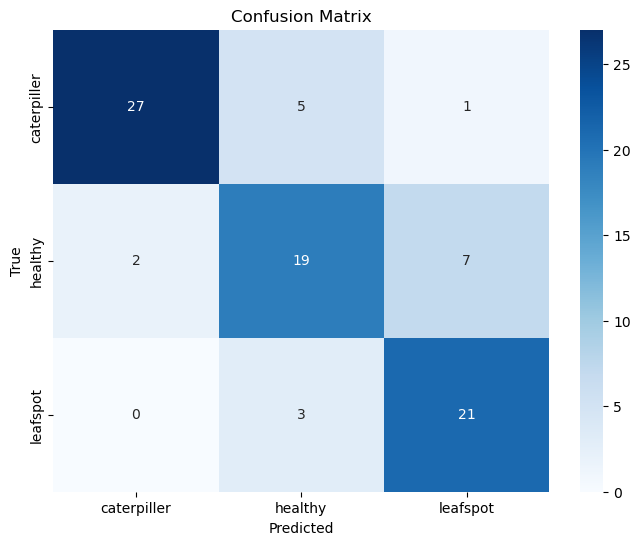

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Evaluate the model on the test data
test_results = model.evaluate(test_generator)

# Make predictions on the test data
y_pred = model.predict(test_generator)
# Convert one-hot encoded labels back to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Get the actual class labels from the test generator
y_true = test_generator.classes

# Generate the classification report
class_report = classification_report(y_true, y_pred_classes, target_names=test_generator.class_indices)

print("Classification Report:")
print(class_report)

# Generate the confusion matrix
confusion_mat = confusion_matrix(y_true, y_pred_classes)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mat, annot=True, fmt="d", cmap="Blues", xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
